In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from dataset import NNUEIterableDataset

In [2]:
dataloader = DataLoader(
    NNUEIterableDataset("../data/nnue/dataset_v0/val", batch_size=1000, random_hflip=False, hflip=False),
    batch_size=None,
    num_workers=2,
    persistent_workers=True,
    prefetch_factor=4,
)

# flip_dataloader = DataLoader(
#     NNUEIterableDataset("../data/nnue/dataset_v0/val", batch_size=1000, random_hflip=False, hflip=True),
#     batch_size=None,
#     num_workers=2,
#     persistent_workers=True,
#     prefetch_factor=4,
# )

In [3]:
buckets = np.linspace(-10000, 10000, 100)
counts = np.zeros(100)
wins = np.zeros(100)

idx_counts = np.zeros(2344*11)

# for (batch, flip_batch) in zip(dataloader, flip_dataloader):
for batch in dataloader:
    b, w, s, r, t = batch

    # flip_b, flip_w, flip_s, flip_r, flip_t = flip_batch

    # b = torch.cat([b, flip_b], dim=0)
    # w = torch.cat([w, flip_w], dim=0)
    # s = torch.cat([s, flip_s], dim=0)
    # r = torch.cat([r, flip_r], dim=0)
    # t = torch.cat([t, flip_t], dim=0)

    np.add.at(idx_counts, b.flatten(), 1)
    np.add.at(idx_counts, w.flatten(), 1)

    s = np.clip(s, -10000, 10000)

    # digitize returns the indices of the buckets [1, ..., len(buckets)]
    bin_indices = np.digitize(s, buckets) - 1  # Shift to zero-indexed

    # keep only scores that fell within the buckets
    mask = (bin_indices >= 0) & (bin_indices < len(buckets))
    bin_indices = bin_indices[mask]
    r_valid = r[mask]

    # Update counts and wins per bucket
    counts += np.bincount(bin_indices, minlength=len(buckets))
    wins += np.bincount(bin_indices, weights=r_valid, minlength=len(buckets))

# total = counts.sum() / 2 # remove the flip counts
total = counts.sum()
print(f'total: {total.item()}')

perf = wins / counts

total: 23351217.0


In [4]:
num_kb = 11
num_features = len(idx_counts)
kb_features = num_features // num_kb
total_features = idx_counts.sum()
counts_per_kb = np.zeros(num_kb)
for i in range(num_kb):
    counts_per_kb[i] = idx_counts[i*kb_features:(i+1)*kb_features].sum()
print(counts_per_kb)

for i in range(num_kb):
    print(f"KB {i+1}: {(counts_per_kb[i]/total_features * 100):.3f}%")


[3.7094900e+08 2.2249060e+08 2.7195660e+08 3.1528760e+07 1.1456180e+08
 6.3016640e+07 1.1424588e+08 1.5921608e+08 1.1677032e+08 2.0769160e+08
 1.9567008e+08]
KB 1: 19.857%
KB 2: 11.910%
KB 3: 14.558%
KB 4: 1.688%
KB 5: 6.133%
KB 6: 3.373%
KB 7: 6.116%
KB 8: 8.523%
KB 9: 6.251%
KB 10: 11.118%
KB 11: 10.474%


In [5]:
buckets = buckets / (127*64)

In [6]:
targets = torch.sigmoid(torch.tensor(buckets*3)).numpy()

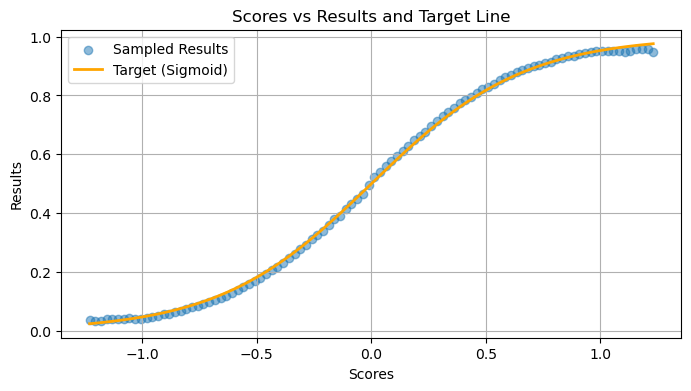

In [7]:
plt.figure(figsize=(8, 4))
plt.scatter(buckets, perf, alpha=0.5, label='Sampled Results')
plt.plot(buckets, targets, color='orange', label='Target (Sigmoid)', linewidth=2)

plt.xlabel('Scores')
plt.ylabel('Results')
plt.title('Scores vs Results and Target Line')
# plt.xlim(-10000, 10000)
plt.grid(True)
plt.legend()
plt.show()

In [8]:
empty_idxs = np.where(idx_counts == 0)[0]
print(f'{empty_idxs.shape[0]} empty features')
# print(f'{empty_idxs.shape[0] - ((9*4*2 + 81-9)*9)} after removing impossible features')
# for idx in empty_idxs:
#     print(idx)


4478 empty features
